# Tutorial: SECTOR on imaging-based spatial transcriptomics data

This notebook demonstrates how to run **SECTOR** on representative imaging-based spatial transcriptomics (ST) datasets used in the manuscript:

1. **MERFISH mouse hypothalamus** (slice `Bregma=-0.24`)
2. **STARmap mouse cortex** (slice `20180424_BZ14_control`)
3. **BaristaSeq mouse primary visual cortex** (slice `2`)

The same workflow can be adapted to custom imaging-based ST datasets: prepare an `.h5ad` file, specify the dataset path and key parameters, train SECTOR, infer spatial domains and pseudotime, and inspect the output. These examples use representative slices from the imaging-based benchmark group in the manuscript.

Compared with whole-transcriptome sequencing-based ST, imaging-based datasets often contain **single-cell or near-single-cell spatial locations** and **targeted gene panels**. The main tuning considerations are therefore spatial smoothing (`lambda_tv`), graph connectivity (`k` and `k_s`), cluster usage/balance settings and post hoc island cleaning. If the requested number of HVGs exceeds the targeted panel size, SECTOR retains the available informative genes after preprocessing.

Guidance on adapting this notebook to custom imaging-based ST datasets and diagnosing common failure modes is provided at the end of the notebook.


## Example 1: MERFISH mouse hypothalamus (slice `Bregma=-0.24`)

This example uses a representative MERFISH mouse hypothalamus slice from the imaging-based benchmark group. The annotation column is `Region`, containing major hypothalamic and associated anatomical regions. SECTOR is run in evaluation mode so that NMI, HOM and COM can be reported after prediction. These annotations are used only for evaluation and are not used during model training.


### 1. Load the SECTOR package


In [1]:
from sector import SECTOR

### 2. Check the expected input format


SECTOR takes an `.h5ad` file that can be loaded as an `AnnData` object. For a custom dataset, the object should contain:

- `adata.X`: expression matrix, preferably raw counts or count-like values; dense and sparse matrices are both supported.
- `adata.obsm["spatial"]`: two-dimensional spatial coordinates with shape `n_obs × 2`.
- Optional `adata.obs[label_key]`: ground-truth annotation used only for evaluation when `eval_mode=1`.

Below, we inspect the MERFISH input object used in this tutorial.


In [2]:
import scanpy as sc

input_adata = sc.read_h5ad('./data/merfish/MERFISH_0.24.h5ad')
input_adata

AnnData object with n_obs × n_vars = 5543 × 155
    obs: 'cell_class', 'neuron_class', 'domain', 'Region'
    uns: 'domain_colors'
    obsm: 'spatial'

`adata.X` should contain the expression matrix. During training, SECTOR performs its own preprocessing, including low-expression gene filtering (`min_cells=5` by default), total-count normalisation (`target_sum=1e4` by default), HVG selection (`n_top_genes=2000` by default), and PCA (`n_comps=20` by default). For targeted imaging panels, if the requested number of HVGs is larger than the panel size after filtering, SECTOR retains the available informative genes.


In [3]:
input_adata.X

array([[0.0000000e+00, 0.0000000e+00, 1.8998619e+01, ..., 0.0000000e+00,
        3.2251249e-03, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 5.0442162e+00, ..., 0.0000000e+00,
        6.6017942e-03, 1.8258397e-02],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 1.8325221e-02],
       ...,
       [0.0000000e+00, 0.0000000e+00, 6.0040540e-01, ..., 2.4402591e-03,
        1.4858560e-03, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 4.7472486e+00, ..., 2.0542040e-02,
        0.0000000e+00, 2.7345980e-03]], shape=(5543, 155), dtype=float32)

The input object should also contain spatial coordinates in `adata.obsm["spatial"]`. These coordinates are used to construct the spatial neighbourhood graph.


In [4]:
input_adata.obsm['spatial']

array([[-3749.176078, -3749.458442],
       [-3746.22621 , -3742.259347],
       [-3742.897643, -3790.648737],
       ...,
       [-2005.542176, -2318.036961],
       [-2121.481564, -2316.58132 ],
       [-1984.998774, -2115.708268]], shape=(5543, 2))

If annotations are available, they can be stored in `adata.obs`. In this MERFISH example, the annotation column is `Region`. SECTOR is label-free: this column is used only when `eval_mode=1` to compute evaluation metrics.


In [5]:
input_adata.obs['Region']

Unnamed: 0
-3749x-3749    MPA
-3746x-3742    MPA
-3743x-3791    MPA
-3738x-3773    MPA
-3736x-3896    MPA
              ... 
-2149x-2317     fx
-2139x-2307     fx
-2006x-2318     fx
-2121x-2317     fx
-1985x-2116     fx
Name: Region, Length: 5543, dtype: category
Categories (8, object): ['BST', 'MPA', 'MPN', 'PV', 'PVH', 'PVT', 'V3', 'fx']

### 3. Initialise a SECTOR model


SECTOR loads data using the path convention:

```text
dataset_path / dataset / slice.h5ad
```

This structure is convenient when a project contains multiple datasets or multiple slices per dataset.

Key dataset and evaluation parameters:

- `dataset_path`: root directory containing the ST datasets.
- `dataset`: dataset folder name.
- `slice`: file name without the `.h5ad` suffix.
- `num_clusters`: expected number of spatial domains.
- `eval_mode`: set to `1` when annotations are available and evaluation metrics should be reported; set to `0` for unannotated custom datasets.
- `label`: annotation column in `adata.obs`, required only when `eval_mode=1`.

Key graph and feature parameters:

- `n_top_genes`: number of HVGs used for feature construction ($N_{HVG}$ in the manuscript), default `2000`. For targeted panels, this often retains all available informative genes.
- `n_comps`: number of PCA components used as input features ($d$ in the manuscript), default `20`.
- `k`: number of neighbours for feature-graph construction ($k_{feat}$ in the manuscript), default `1`.
- `k_s`: number of neighbours for spatial-graph construction, default `6`.


In [6]:
m = SECTOR(
    # input slice path
    dataset_path='./data',       # Root directory for ST datasets.
    dataset='merfish',           # MERFISH mouse hypothalamus dataset.
    slice='MERFISH_0.24',        # Slice file name without the .h5ad suffix.

    # evaluation and output
    num_clusters=8,              # Expected number of spatial domains.
    eval_mode=1,                 # Evaluation mode; annotations are used only for metric calculation.
    label='Region',              # Ground-truth annotation column in adata.obs, required when eval_mode=1.

    # key graph and feature parameters
    n_comps=20,                  # Number of PCA components (d in the manuscript).
    n_top_genes=2000,            # Number of HVGs; targeted panels may retain all informative genes.
    k=1,                         # Feature-graph neighbours (k_feat in the manuscript).
    k_s=6,                       # Spatial-graph neighbours.
)


Device: cuda:0
[Preprocess] Using HVG features (n_top_genes=2000, mode=small/dense)
Dataset Name: merfish
Number of nodes: 5543
Number of edges: 21946
Number of features: 20
Number of classes: 8 (labels loaded: True)
Feature: torch.Size([5543, 20])
edge_index: torch.Size([2, 43893])


### 4. Train the SECTOR model


Important training parameters:

- `lambda_tv`: spatial total-variation (TV) coefficient. Larger values enforce stronger spatial smoothness; smaller values preserve sharper local boundaries. Imaging-based datasets with narrow adjacent domains can be sensitive to excessive smoothing. We recommend `lambda_tv=2.0` for MERFISH as a starting point.
- `lr`: learning rate for Adam optimisation, default `0.001`.
- `stability_nmi_thr`: label-free early-stopping threshold based on assignment stability between epochs. We recommend `stability_nmi_thr=0.99` for imaging-based ST data.
- `balance_mode`: how cluster usage is measured in the optional balance prior. `node` mode is often intuitive for single-cell imaging data because it balances by the number of cells; `volume` mode can also be used to reproduce specific benchmark settings.
- `balance_probe_epochs`: number of initial probe epochs used to detect severe under-use of clusters. A longer probe, such as `balance_probe_epochs=200`, can be useful for imaging-based data.
- `gamma_balance`: balance-regularisation weight, used only if the balance probe detects cluster under-use. For imaging-based data, `0.1` is a conservative starting point; increase it only if cluster under-use persists. This MERFISH example uses a stronger value to reproduce the benchmark setting.


In [7]:
m.fit(
    lambda_tv=2.0,              # Spatial TV regularisation coefficient.
    lr=0.001,                   # Learning rate.
    stability_nmi_thr=0.99,     # Label-free early-stopping threshold based on assignment stability.
    balance_mode='node',        # Node-based balance is often natural for single-cell imaging data.
    balance_probe_epochs=200,   # Number of balance-probe epochs.
    gamma_balance=1.0,          # Stronger benchmark setting; used only if the probe detects cluster under-use.
)


[Probe] Starting 200 epochs with balance OFF...
[Probe] Epoch 0 | Loss=10.346745 | UsedK=8/8
[Probe] Epoch 20 | Loss=10.283879 | UsedK=8/8
[Probe] Epoch 40 | Loss=10.137836 | UsedK=8/8
[Probe] Epoch 60 | Loss=10.003764 | UsedK=8/8
[Probe] Epoch 80 | Loss=9.869637 | UsedK=8/8
[Probe] Epoch 100 | Loss=9.717827 | UsedK=8/8
[Probe] Epoch 120 | Loss=9.479407 | UsedK=8/8
[Probe] Epoch 140 | Loss=9.265209 | UsedK=8/8
[Probe] Epoch 160 | Loss=9.108825 | UsedK=8/8
[Probe] Epoch 180 | Loss=9.003513 | UsedK=8/8
[Probe] Epoch 199 | Loss=8.919552 | UsedK=8/8
[Continue] K stable at end of probe. Continuing with balance OFF.
Epoch: 200 [0.040s], Loss: 8.908728, NMI: 0.626030, HOM: 0.608229, COM: 0.644905, K: 8/8, 
Epoch: 201 [0.038s], Loss: 8.914566, NMI: 0.624995, HOM: 0.606510, COM: 0.644643, K: 8/8, 
Epoch: 202 [0.038s], Loss: 8.907701, NMI: 0.623520, HOM: 0.605688, COM: 0.642435, K: 8/8, 
Epoch: 203 [0.037s], Loss: 8.904875, NMI: 0.623417, HOM: 0.605580, COM: 0.642338, K: 8/8, 
Epoch: 204 [0.037s

### 5. Infer and visualise spatial domains and pseudotime

Prediction-related parameters:

- `spatial_anchor`: orients the inferred pseudotime using a broad spatial direction, such as `"south"`, `"north"`, `"east"` or `"west"`.
- `root_cluster`: alternatively, users can manually orient pseudotime by specifying a predicted cluster as the starting point after inspecting the spatial domains.
- `plot`: if `True`, spatial-domain and pseudotime plots are generated and saved.
- `island_min_frac` and `island_min_abs`: optional post hoc island-cleaning parameters that reduce small disconnected fragments. For many imaging-based datasets, modest island cleaning (`island_min_frac=0.03` and `island_min_abs=20`) can improve spatial continuity.

For custom datasets, inspect the predicted domains first, then adjust `spatial_anchor`, `root_cluster` and island-cleaning settings if needed.


[Post hoc] Island cleaner changed 102 spots (min_abs=20, min_frac=0.03, max_iter=2)
[Final metrics] NMI=0.681280, HOM=0.664947, COM=0.698437, (K=8/8)


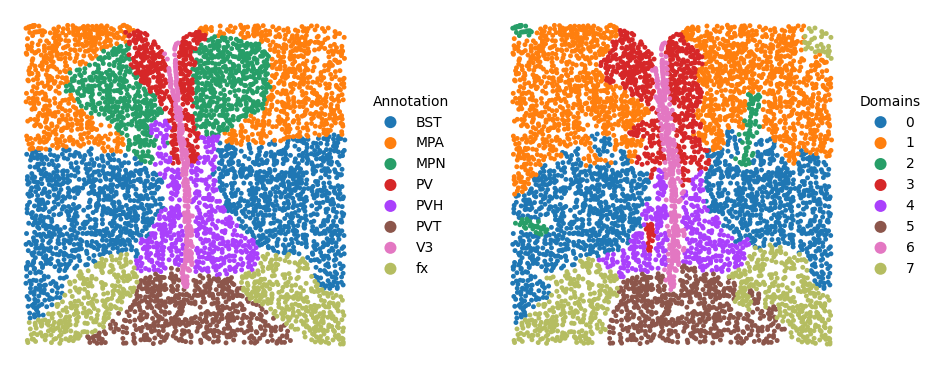

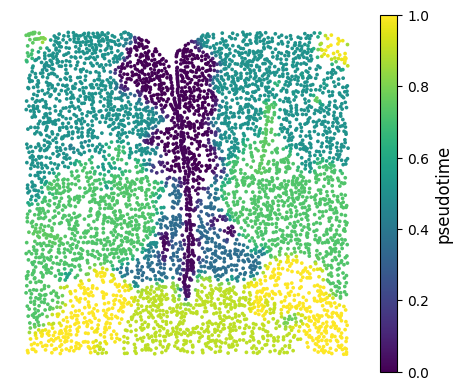

In [8]:
adata = m.pred(
    spatial_anchor='north',     # Pseudotime orientation; root_cluster can be used instead after inspecting domains.
    plot=True,                  # If True, spatial domains and pseudotime are plotted and saved.
    island_min_frac=0.03,       # Relative minimum component size for post hoc island cleaning.
    island_min_abs=20,          # Absolute minimum component size for post hoc island cleaning.
)


### 6. Inspect evaluation metrics


When `eval_mode=1`, final clustering metrics are stored in `adata.uns["SECTOR"]["final_metrics"]`. These include NMI, HOM and COM, which are the main clustering metrics reported in the manuscript.


In [9]:
print('NMI:', adata.uns['SECTOR']['final_metrics']['NMI'])
print('HOM:', adata.uns['SECTOR']['final_metrics']['HOM'])
print('COM:', adata.uns['SECTOR']['final_metrics']['COM'])

NMI: 0.681280437523326
HOM: 0.6649466615765763
COM: 0.6984368682232867


## Example 2: STARmap mouse cortex (slice `20180424_BZ14_control`)

This example uses a representative STARmap mouse cortex slice from the imaging-based benchmark group. STARmap slices have fewer spatial locations than MERFISH but can be relatively sparse and heterogeneous. In the manuscript sensitivity analysis, stronger spatial regularisation was useful for some STARmap slices, so this example uses `lambda_tv=4.0`.


In [10]:
m = SECTOR(
    dataset_path='./data',                 # Root directory for ST datasets.
    dataset='starmap',                     # STARmap mouse cortex dataset.
    slice='20180424_BZ14_control',         # Slice file name without the .h5ad suffix.
    label='Region',                        # Ground-truth annotation column in adata.obs.
    num_clusters=4,                        # Expected number of spatial domains.
    eval_mode=1,                           # Evaluation mode; annotations are used only for metric calculation.
)


Device: cuda:0
[Preprocess] Using HVG features (n_top_genes=2000, mode=small/dense)
Dataset Name: starmap
Number of nodes: 1088
Number of edges: 4291
Number of features: 20
Number of classes: 4 (labels loaded: True)
Feature: torch.Size([1088, 20])
edge_index: torch.Size([2, 8582])


In [11]:
m.fit(
    lambda_tv=4.0,              # Stronger spatial TV regularisation for this STARmap slice.
    stability_nmi_thr=0.99,     # Label-free early-stopping threshold based on assignment stability.
    balance_mode='node',        # Node-based balance for cell-level data.
    gamma_balance=0.1,          # Balance weight, used only if the probe detects cluster under-use.
)


[Probe] Starting 20 epochs with balance OFF...
[Probe] Epoch 0 | Loss=8.083493 | UsedK=4/4
[Probe] Epoch 19 | Loss=8.102683 | UsedK=4/4
[Continue] K stable at end of probe. Continuing with balance OFF.
Epoch: 20 [0.028s], Loss: 8.102233, NMI: 0.366593, HOM: 0.395654, COM: 0.341509, K: 4/4, 
Epoch: 21 [0.028s], Loss: 8.107795, NMI: 0.367875, HOM: 0.397135, COM: 0.342630, K: 4/4, 
Epoch: 22 [0.029s], Loss: 8.106714, NMI: 0.378115, HOM: 0.406658, COM: 0.353315, K: 4/4, 
Epoch: 23 [0.028s], Loss: 8.103853, NMI: 0.403005, HOM: 0.432911, COM: 0.376964, K: 4/4, 
Epoch: 24 [0.028s], Loss: 8.107665, NMI: 0.384313, HOM: 0.411344, COM: 0.360616, K: 4/4, 
Epoch: 25 [0.028s], Loss: 8.106362, NMI: 0.398541, HOM: 0.429074, COM: 0.372065, K: 4/4, 
Epoch: 26 [0.028s], Loss: 8.106496, NMI: 0.435129, HOM: 0.462570, COM: 0.410762, K: 4/4, 
Epoch: 27 [0.028s], Loss: 8.108817, NMI: 0.436839, HOM: 0.463817, COM: 0.412826, K: 4/4, 
Epoch: 28 [0.028s], Loss: 8.107992, NMI: 0.446437, HOM: 0.473795, COM: 0.42206

[Post hoc] Island cleaner changed 4 spots (min_abs=20, min_frac=0.03, max_iter=2)
[Final metrics] NMI=0.805686, HOM=0.792465, COM=0.819356, (K=4/4)


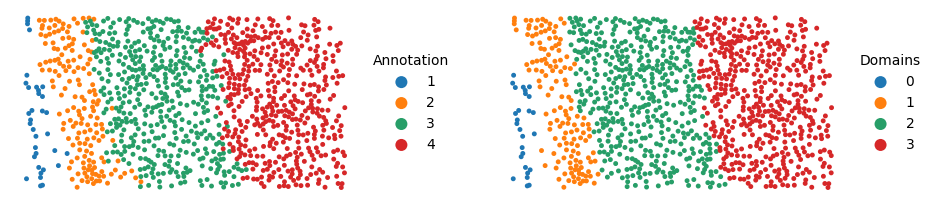

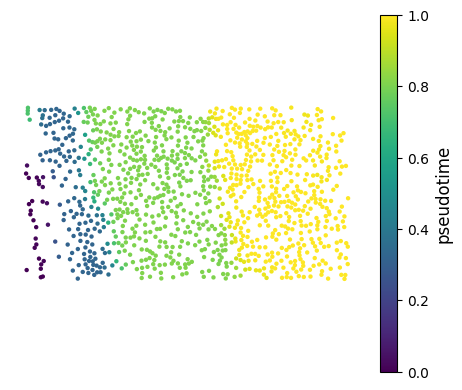

In [12]:
adata = m.pred(
    spatial_anchor='south',     # Pseudotime orientation; root_cluster can be used instead after inspecting domains.
    plot=True,                  # If True, spatial domains and pseudotime are plotted and saved.
    island_min_frac=0.03,       # Relative minimum component size for post hoc island cleaning.
    island_min_abs=20,          # Absolute minimum component size for post hoc island cleaning.
)


In [13]:
print('NMI:', adata.uns['SECTOR']['final_metrics']['NMI'])
print('HOM:', adata.uns['SECTOR']['final_metrics']['HOM'])
print('COM:', adata.uns['SECTOR']['final_metrics']['COM'])

NMI: 0.805685753705181
HOM: 0.7924645086663071
COM: 0.8193556425207472


## Example 3: BaristaSeq mouse primary visual cortex (slice `2`)

This example uses a representative BaristaSeq primary visual cortex slice. BaristaSeq is a targeted-panel, single-cell-resolution dataset with laminar annotations. Because the domains are narrow and adjacent, the manuscript sensitivity analysis showed that overly strong spatial TV regularisation can blur neighbouring layers. We therefore use a moderate value, `lambda_tv=2.0`, and keep the post hoc island-cleaning thresholds modest.


In [14]:
m = SECTOR(
    dataset_path='./data',       # Root directory for ST datasets.
    dataset='baristaseq',        # BaristaSeq mouse primary visual cortex dataset.
    slice='Slice_2_removed',     # Slice file name without the .h5ad suffix.
    label='Region',              # Ground-truth annotation column in adata.obs.
    num_clusters=6,              # Expected number of spatial domains.
    eval_mode=1,                 # Evaluation mode; annotations are used only for metric calculation.
)


Device: cuda:0
[Preprocess] Using HVG features (n_top_genes=2000, mode=small/dense)
Dataset Name: baristaseq
Number of nodes: 2042
Number of edges: 8067
Number of features: 20
Number of classes: 6 (labels loaded: True)
Feature: torch.Size([2042, 20])
edge_index: torch.Size([2, 16134])


In [15]:
m.fit(
    lambda_tv=2.0,              # Moderate spatial TV regularisation to avoid over-smoothing laminar boundaries.
    stability_nmi_thr=0.99,     # Label-free early-stopping threshold based on assignment stability.
    balance_mode='volume',      # Benchmark setting used for this BaristaSeq slice.
    balance_probe_epochs=200,   # Number of balance-probe epochs.
    gamma_balance=0.1,          # Balance weight, used only if the probe detects cluster under-use.
)


[Probe] Starting 200 epochs with balance OFF...
[Probe] Epoch 0 | Loss=9.027280 | UsedK=6/6
[Probe] Epoch 20 | Loss=9.028835 | UsedK=6/6
[Probe] Epoch 40 | Loss=8.996611 | UsedK=6/6
[Probe] Epoch 60 | Loss=8.951162 | UsedK=6/6
[Probe] Epoch 80 | Loss=8.856670 | UsedK=6/6
[Probe] Epoch 100 | Loss=8.702601 | UsedK=6/6
[Probe] Epoch 120 | Loss=8.474281 | UsedK=6/6
[Probe] Epoch 140 | Loss=8.267199 | UsedK=6/6
[Probe] Epoch 160 | Loss=8.069395 | UsedK=6/6
[Probe] Epoch 180 | Loss=7.934231 | UsedK=6/6
[Probe] Epoch 199 | Loss=7.844441 | UsedK=6/6
[Continue] K stable at end of probe. Continuing with balance OFF.
Epoch: 200 [0.029s], Loss: 7.835186, NMI: 0.724535, HOM: 0.715471, COM: 0.733832, K: 6/6, 
Epoch: 201 [0.030s], Loss: 7.836080, NMI: 0.722121, HOM: 0.713928, COM: 0.730503, K: 6/6, 
Epoch: 202 [0.029s], Loss: 7.850621, NMI: 0.719197, HOM: 0.711361, COM: 0.727208, K: 6/6, 
Epoch: 203 [0.029s], Loss: 7.823118, NMI: 0.712844, HOM: 0.704525, COM: 0.721361, K: 6/6, 
Epoch: 204 [0.029s], L

[Post hoc] Island cleaner changed 50 spots (min_abs=20, min_frac=0.03, max_iter=2)
[Final metrics] NMI=0.783494, HOM=0.775692, COM=0.791455, (K=6/6)


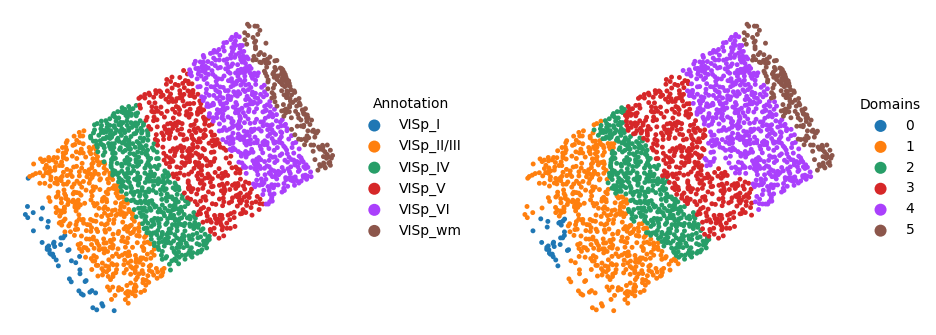

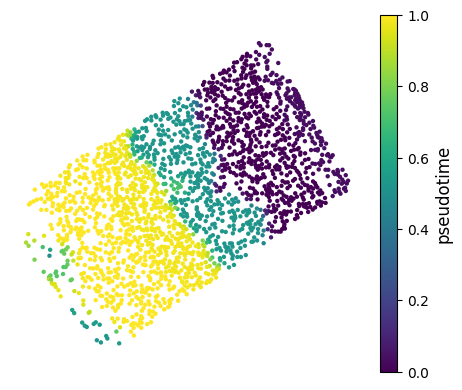

In [16]:
adata = m.pred(
    spatial_anchor='north',     # Pseudotime orientation; root_cluster can be used instead after inspecting domains.
    plot=True,                  # If True, spatial domains and pseudotime are plotted and saved.
    island_min_frac=0.03,       # Relative minimum component size for post hoc island cleaning.
    island_min_abs=20,          # Absolute minimum component size for post hoc island cleaning.
)


In [17]:
print('NMI:', adata.uns['SECTOR']['final_metrics']['NMI'])
print('HOM:', adata.uns['SECTOR']['final_metrics']['HOM'])
print('COM:', adata.uns['SECTOR']['final_metrics']['COM'])

NMI: 0.7834938686539228
HOM: 0.7756917176745103
COM: 0.7914545673270291


## Adapting this notebook to a custom imaging-based ST dataset

For a new dataset, use the following checklist:

1. Save the data as an `.h5ad` file under `dataset_path / dataset / slice.h5ad`.
2. Ensure that `adata.X` contains the expression matrix and `adata.obsm["spatial"]` contains two-dimensional spatial coordinates.
3. If ground-truth annotations are available, store them in `adata.obs` and set `eval_mode=1` with the corresponding `label`; otherwise set `eval_mode=0`.
4. Set `num_clusters` to the expected number of spatial domains. If this is unknown, try a small range of plausible values and inspect both spatial maps and biological markers.
5. Tune the main dataset-dependent parameters:
   - `lambda_tv`: increase if domains are fragmented or noisy; decrease if boundaries are oversmoothed.
   - `k_s`: controls the spatial graph. Larger values enforce broader spatial neighbourhoods; smaller values preserve local boundaries.
   - `k`: controls the feature graph. Increasing it can connect similar cells, but overly large values may over-aggregate heterogeneous regions.
   - `n_top_genes`: for targeted panels, this often retains the available informative genes; for larger panels, tune this value as in the manuscript sensitivity analysis.
   - `n_comps`: PCA dimension. Moderate values are usually stable, but larger or more heterogeneous panels may benefit from additional components.
6. Keep the balance probe enabled. If clusters are severely under-used, start from a small `gamma_balance` such as `0.1` for imaging-based datasets and increase only if necessary. If domains become unnaturally equal-sized, reduce the balance weight or reconsider `num_clusters`.
7. Use post hoc island cleaning cautiously. It can remove isolated noisy components, but overly aggressive cleaning may remove small biologically meaningful structures.
8. Use `spatial_anchor` for a broad directional pseudotime orientation, or use `root_cluster` after inspecting the predicted spatial domains.


## Diagnostics on common failure modes

SECTOR is generally robust across moderate parameter ranges, but different tissues and spatial technologies may require limited tuning. Use the patterns below to diagnose common issues and choose targeted adjustments.

### 1. Oversmoothed domains

**Typical pattern:** neighbouring anatomical regions are merged, narrow boundaries disappear, or small biologically meaningful domains are absorbed into larger regions.

Possible adjustments:

- Decrease `lambda_tv` to reduce spatial smoothing.
- Reduce spatial or feature-graph connectivity by decreasing `k_s` and/or `k`.
- Reduce post hoc island-cleaning strength by decreasing `island_min_frac` and/or `island_min_abs`.

### 2. Fragmented or noisy domains

**Typical pattern:** predicted domains contain many isolated islands, boundaries are noisy, or spatially coherent tissue regions are split into many small pieces.

Possible adjustments:

- Increase `lambda_tv` to encourage spatial coherence.
- Increase spatial or feature-graph connectivity by increasing `k_s` and/or `k`.
- Apply modest island cleaning by slightly increasing `island_min_frac` and/or `island_min_abs`.

### 3. Under-used clusters

**Typical pattern:** the number of occupied predicted clusters is smaller than `num_clusters`, or one or more clusters contain very few spots/cells.

Possible adjustments:

- Keep the balance probe enabled so SECTOR first tests whether all clusters are naturally used with `gamma_balance=0`.
- Increase `gamma_balance` only if cluster under-use persists after the balance probe.
- Reconsider whether `num_clusters` is biologically reasonable; persistent under-use can indicate that the requested number of domains is larger than the tissue structure supports.
- For large or highly heterogeneous datasets, also tune `lr`, because unstable optimisation can contribute to poor cluster usage.

### 4. Unstable training or poor convergence

**Typical pattern:** results vary substantially across runs or slices, cluster usage changes abruptly, or training does not stabilise.

Possible adjustments:

- Reduce `lr` if optimisation appears unstable, especially for large or highly heterogeneous datasets.
- Increase `epochs` if the model has not converged.
- Check whether early stopping is too aggressive for the dataset.
- Keep the random seed fixed when comparing parameter settings.

### 5. High memory usage

**Typical pattern:** graph construction becomes slow, GPU/CPU memory is exhausted, or training becomes impractical.

Possible adjustments:

- Keep `large_scale_mode="auto"`. SECTOR will automatically switch from dense to sparse graph construction for larger datasets.
- For very large datasets, SECTOR further reduces memory usage by constructing the feature graph from the PCA representation rather than repeatedly updating it from a changing neural representation.
- The default `large_scale_n_obs_threshold` is `100000`; users can adjust this threshold according to their hardware.
- For whole-transcriptome or large-panel datasets, reduce `n_top_genes` and/or `n_comps` to lower the memory cost of feature construction.
- Reducing `k_s` and/or `k` can also reduce graph size, but may affect spatial continuity and should be tuned together with `lambda_tv`.
